# Automatització híbrida SARIMA + NNAR estacional per a 180 sèries setmanals

Aquest notebook automatitza l’enfocament híbrid utilitzat al TFG. Per a cada sèrie, es parteix del model SARIMA seleccionat prèviament i es modelitzen els residus amb una xarxa neuronal autoregressiva estacional.

L’objectiu és obtenir una taula resum amb les mètriques del model híbrid i un fitxer amb les prediccions setmanals del període de test.

In [1]:
import numpy as np
import pandas as pd
from itertools import product
import warnings
import matplotlib.pyplot as plt
import ast

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import InterpolationWarning
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning
from IPython.display import display

COLOR_TRAIN = '#1f77b4'   
COLOR_OBS = '#ffbf00'      
COLOR_FORECAST = '#6a0dad' 
COLOR_HYBRID = "#009688"

df = pd.read_csv("dades_net.csv", sep=",")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["nom_regio", "diagnostic", "edat_bin", "date"]).copy()

## Resultats SARIMA previs

Es carreguen els resultats del SARIMA ja seleccionat per a cada sèrie. Només es processen les combinacions amb estat `ok`.

In [2]:
sarima_results = pd.read_csv("results_sarima.csv")

required_cols = [
    "age", "diag", "region",
    "order", "seasonal",
    "status"
]

missing_cols = [c for c in required_cols if c not in sarima_results.columns]
if missing_cols:
    raise ValueError(f"Missing columns in SARIMA results CSV: {missing_cols}")

sarima_results_ok = sarima_results[sarima_results["status"] == "ok"].copy()
combinacions = list(sarima_results_ok[["age", "diag", "region"]].itertuples(index=False, name=None))

print("Total series in data:", df[["edat_bin", "diagnostic", "nom_regio"]].drop_duplicates().shape[0])
print("Total valid SARIMA series to run in hybrid automation:", len(combinacions))

Total series in data: 180
Total valid SARIMA series to run in hybrid automation: 174


In [3]:
def make_series(df, age, diag, region):
    sub = df[
        (df["edat_bin"] == age) &
        (df["diagnostic"] == diag) &
        (df["nom_regio"] == region)
    ].copy()

    s = (
        sub.set_index("date")["taxa_setmanal"]
        .sort_index()
        .asfreq("W-MON")
    )

    return s

def split_series(s):
    train = s[:'2019-12-31'].copy()
    test = s['2020-01-01':].copy()

    train = train.interpolate(method="linear").ffill().bfill()
    test = test.interpolate(method="linear").ffill().bfill()

    return train, test
    
def parse_tuple_string(x):
    if isinstance(x, tuple):
        return x
    if pd.isna(x):
        raise ValueError("Found missing value where a tuple string was expected.")
    
    value = ast.literal_eval(str(x))
    
    if not isinstance(value, tuple):
        raise ValueError(f"Expected tuple, got {type(value)} from value: {x}")
    
    return value


def get_sarima_row(sarima_results_ok, age, diag, region):
    row = sarima_results_ok[
        (sarima_results_ok["age"] == age) &
        (sarima_results_ok["diag"] == diag) &
        (sarima_results_ok["region"] == region)
    ]
    
    if len(row) == 0:
        raise ValueError(
            f"No SARIMA result found for series: age={age}, diag={diag}, region={region}"
        )
    
    if len(row) > 1:
        raise ValueError(
            f"More than one SARIMA result found for series: age={age}, diag={diag}, region={region}"
        )
    
    return row.iloc[0]

def get_sarima_spec(sarima_results_ok, age, diag, region):
    row = get_sarima_row(sarima_results_ok, age, diag, region)

    order = parse_tuple_string(row["order"])
    seasonal = parse_tuple_string(row["seasonal"])

    return row, order, seasonal

## SARIMA seleccionat i residus

S’ajusta el SARIMA seleccionat prèviament sobre el conjunt d’entrenament i s’extreuen els residus. Després s’elimina el període inicial de burn-in abans d’entrenar el NNAR.

In [4]:
def fit_selected_sarima(train, order, seasonal):
    model = SARIMAX(
        train,
        order=order,
        seasonal_order=seasonal,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res = model.fit(disp=False)

    return res

def get_sarima_residuals_for_nnar(res, min_burn=52, seasonal_period=52, return_all=False):
    residuals = res.resid.dropna().copy()

    loglik_burn = getattr(res, "loglikelihood_burn", 0)
    diffuse_burn = getattr(res.filter_results, "nobs_diffuse", 0)

    burn = int(max(min_burn, seasonal_period, loglik_burn, diffuse_burn))

    if burn >= len(residuals):
        raise ValueError(
            f"Burn ({burn}) is greater than or equal to residual length ({len(residuals)})."
        )

    residuals_burned = residuals.iloc[burn:].copy()

    if return_all:
        return residuals, residuals_burned, burn

    return residuals_burned, burn

def get_metrics_hybrid(test, pred):
    pred = pred.copy().reindex(test.index)

    mae = mean_absolute_error(test, pred)
    rmse = np.sqrt(mean_squared_error(test, pred))

    return pred, mae, rmse


def pct_improvement(old, new):
    if pd.isna(old) or old == 0:
        return np.nan
    return 100 * (old - new) / old

## NNAR sobre els residus

Es construeix una matriu supervisada amb retards no estacionals i un retard estacional de 52 setmanes. Les configuracions candidates es comparen amb validació rolling.

In [5]:
p_list = [2, 3, 4, 5, 6, 8, 12]
hidden_list = [2, 3, 4, 6, 8]

def create_nnar_matrix(series, p=2, seasonal_lag=52):
    df_nn = pd.DataFrame({"y": series})

    for i in range(1, p + 1):
        df_nn[f"lag_{i}"] = df_nn["y"].shift(i)

    df_nn[f"lag_seasonal_{seasonal_lag}"] = df_nn["y"].shift(seasonal_lag)

    df_nn = df_nn.dropna()

    X = df_nn.drop(columns="y")
    y = df_nn["y"]

    return X, y

def fit_nnar_grid(residuals_train, p_list, hidden_list, seasonal_lag=52, start_frac=0.7, horizon=26, step=26):
    results_grid = []

    if len(residuals_train) <= seasonal_lag + max(p_list) + 10:
        return None

    for p in p_list:
        for hidden in hidden_list:
            cv_mae, cv_rmse, n_folds = rolling_validation_nnar_recursive(
                residuals_train,
                p=p,
                hidden=hidden,
                seasonal_lag=seasonal_lag,
                start_frac=start_frac,
                horizon=horizon,
                step=step
            )

            if pd.isna(cv_mae):
                continue

            results_grid.append({
                "p": p,
                "P": 1,
                "m": seasonal_lag,
                "hidden_units": hidden,
                "cv_MAE": cv_mae,
                "cv_RMSE": cv_rmse,
                "n_folds": n_folds,
                "resid_train_size": len(residuals_train)
            })

    if len(results_grid) == 0:
        return None

    results_grid = (
        pd.DataFrame(results_grid)
        .sort_values(["cv_RMSE", "cv_MAE"])
        .reset_index(drop=True)
    )

    return results_grid
    
def fit_final_nnar(residuals_train, p, hidden, seasonal_lag=52): 
    X_full_nn, y_full_nn = create_nnar_matrix(
        residuals_train,
        p=p,
        seasonal_lag=seasonal_lag
    )

    if len(X_full_nn) == 0:
        raise ValueError("NNAR matrix is empty.")

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    X_full_scaled = scaler_X.fit_transform(X_full_nn)
    y_full_scaled = scaler_y.fit_transform(y_full_nn.to_frame()).ravel()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)

        nnar_final = MLPRegressor(
            hidden_layer_sizes=(hidden,),
            activation="relu",
            solver="lbfgs",
            alpha=1e-4,
            max_iter=5000,
            random_state=42
        )

        nnar_final.fit(X_full_scaled, y_full_scaled)

    feature_names = X_full_nn.columns.tolist()

    return nnar_final, scaler_X, scaler_y, feature_names
    
def recursive_nnar_forecast(model, history, horizon, p, seasonal_lag, scaler_X, scaler_y, feature_names, forecast_index):
    preds = []
    history = list(history)

    for _ in range(horizon):
        row = {}

        for i in range(1, p + 1):
            row[f"lag_{i}"] = history[-i]

        row[f"lag_seasonal_{seasonal_lag}"] = history[-seasonal_lag]

        X_next = pd.DataFrame([row]).reindex(columns=feature_names)
        X_next_scaled = scaler_X.transform(X_next)

        pred_scaled = model.predict(X_next_scaled)
        pred = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()[0]

        preds.append(pred)
        history.append(pred)

    return pd.Series(preds, index=forecast_index)

def rolling_validation_nnar_recursive(residuals_train, p, hidden, seasonal_lag=52, start_frac=0.7, horizon=26, step=26):
    mae_errors = []
    rmse_errors = []

    n = len(residuals_train)
    min_start = seasonal_lag + max(p, 1) + 10
    start = max(int(n * start_frac), min_start)

    end_train = start

    while end_train + horizon <= n:
        train_cv = residuals_train.iloc[:end_train].copy()
        val_cv = residuals_train.iloc[end_train:end_train + horizon].copy()

        try:
            nnar_model, scaler_X, scaler_y, feature_names = fit_final_nnar(
                train_cv,
                p=p,
                hidden=hidden,
                seasonal_lag=seasonal_lag
            )

            pred_cv = recursive_nnar_forecast(
                model=nnar_model,
                history=train_cv.values,
                horizon=len(val_cv),
                p=p,
                seasonal_lag=seasonal_lag,
                scaler_X=scaler_X,
                scaler_y=scaler_y,
                feature_names=feature_names,
                forecast_index=val_cv.index
            )

            mae_cv = mean_absolute_error(val_cv, pred_cv)
            rmse_cv = np.sqrt(mean_squared_error(val_cv, pred_cv))

            mae_errors.append(mae_cv)
            rmse_errors.append(rmse_cv)

        except Exception:
            pass

        end_train += step

    if len(mae_errors) == 0:
        return np.nan, np.nan, 0

    return float(np.mean(mae_errors)), float(np.mean(rmse_errors)), len(mae_errors)

def plot_hybrid_comparison(train, test, sarima_pred, hybrid_pred, low=None, up=None, title=""):
    plt.figure(figsize=(14, 5))
    plt.plot(test.index, test.values, label="test", color=COLOR_OBS, linewidth=1.5)
    plt.plot(sarima_pred.index, sarima_pred.values, label="sarima", color=COLOR_FORECAST, linewidth=1.2, linestyle="--")
    plt.plot(hybrid_pred.index, hybrid_pred.values, label="hybrid", color=COLOR_HYBRID, linewidth=1.2)

    if low is not None and up is not None:
        plt.fill_between(
            hybrid_pred.index,
            low.values,
            up.values,
            color=COLOR_HYBRID,
            alpha=0.08,
            label="hybrid interval"
        )

    plt.title(title)
    plt.legend()
    plt.show()

## Intervals de predicció híbrids

Els intervals del model híbrid s’obtenen mitjançant simulació, combinant la incertesa del SARIMA amb la variabilitat dels errors del NNAR sobre els residus.

In [6]:
def hybrid_pi_automation(
    sarima_result,
    nnar_model,
    scaler_X,
    scaler_y,
    residuals_train,
    X_train_nnar,
    y_train_nnar,
    p,
    seasonal_lag,
    feature_names,
    forecast_index,
    n_sims=100,
    alpha=0.05,
    seed=42
):
    rng = np.random.default_rng(seed)
    h = len(forecast_index)

    X_scaled = scaler_X.transform(X_train_nnar)
    yhat_scaled = nnar_model.predict(X_scaled)
    yhat = scaler_y.inverse_transform(yhat_scaled.reshape(-1, 1)).ravel()

    nnar_errors = np.asarray(y_train_nnar) - yhat
    nnar_errors = nnar_errors - nnar_errors.mean()

    err_low, err_high = np.quantile(nnar_errors, [0.01, 0.99])
    nnar_errors = np.clip(nnar_errors, err_low, err_high)

    sarima_sim = np.asarray(
        sarima_result.simulate(
            nsimulations=h,
            repetitions=n_sims,
            anchor="end",
            random_state=seed
        )
    )

    if sarima_sim.ndim == 1:
        sarima_sim = sarima_sim.reshape(h, 1)
    elif sarima_sim.shape == (n_sims, h):
        sarima_sim = sarima_sim.T

    hybrid_sim = np.zeros((h, n_sims))
    base_history = list(np.asarray(residuals_train, dtype=float))

    resid_low, resid_high = np.quantile(base_history, [0.01, 0.99])

    for b in range(n_sims):
        history = base_history.copy()

        for t in range(h):
            row = {}

            for i in range(1, p + 1):
                row[f"lag_{i}"] = history[-i]

            row[f"lag_seasonal_{seasonal_lag}"] = history[-seasonal_lag]

            X_next = pd.DataFrame([row]).reindex(columns=feature_names)
            X_next_scaled = scaler_X.transform(X_next)

            pred_scaled = nnar_model.predict(X_next_scaled)
            pred_resid = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()[0]
            next_resid = pred_resid + rng.choice(nnar_errors)
            next_resid = np.clip(next_resid, resid_low, resid_high)

            history.append(next_resid)

            total_value = sarima_sim[t, b] + next_resid
            hybrid_sim[t, b] = max(0, total_value)

    lower = pd.Series(
        np.quantile(hybrid_sim, alpha / 2, axis=1),
        index=forecast_index,
        name="hybrid_low"
    )

    upper = pd.Series(
        np.quantile(hybrid_sim, 1 - alpha / 2, axis=1),
        index=forecast_index,
        name="hybrid_up"
    )

    return lower, upper

## Pipeline per a una sèrie

La funció `run_one_hybrid(...)` aplica tot el procés a una combinació concreta: construeix la sèrie, ajusta el SARIMA, modelitza els residus amb NNAR, calcula la predicció híbrida i guarda les mètriques.

In [7]:
SEASONAL_LAG = 52

CV_START_FRAC = 0.7
CV_HORIZON = 26
CV_STEP = 26
HYBRID_PI_NSIMS = 100

def run_one_hybrid(df, sarima_results_ok, age, diag, region):
    s = make_series(df, age, diag, region)
    train, test = split_series(s)

    if len(train) == 0 or len(test) == 0:
        row = {
            "age": age,
            "diag": diag,
            "region": region,
            "status": "fail",
            "error": "empty train or test"
        }
        return row, None, None

    sarima_row, order, seasonal = get_sarima_spec(sarima_results_ok, age, diag, region)

    res_sarima = fit_selected_sarima(train, order, seasonal)

    residuals_train, burn = get_sarima_residuals_for_nnar(
        res_sarima,
        min_burn=SEASONAL_LAG,
        seasonal_period=SEASONAL_LAG
    )

    min_required_residuals = SEASONAL_LAG + max(p_list) + 10
    if len(residuals_train) <= min_required_residuals:
        row = {
            "age": age,
            "diag": diag,
            "region": region,
            "status": "fail",
            "error": f"not enough residuals after burn to fit NNAR (need > {min_required_residuals}, got {len(residuals_train)})"
        }
        return row, None, None

    results_grid = fit_nnar_grid(
        residuals_train,
        p_list=p_list,
        hidden_list=hidden_list,
        seasonal_lag=SEASONAL_LAG,
        start_frac=CV_START_FRAC,
        horizon=CV_HORIZON,
        step=CV_STEP
    )

    if results_grid is None or len(results_grid) == 0:
        row = {
            "age": age,
            "diag": diag,
            "region": region,
            "status": "fail",
            "error": "no NNAR model fitted"
        }
        return row, None, None

    best_config = results_grid.iloc[0]
    best_p = int(best_config["p"])
    best_hidden = int(best_config["hidden_units"])
    best_cv_mae = float(best_config["cv_MAE"])
    best_cv_rmse = float(best_config["cv_RMSE"])
    best_n_folds = int(best_config["n_folds"])

    nnar_final, scaler_X_final, scaler_y_final, feature_names = fit_final_nnar(
        residuals_train,
        p=best_p,
        hidden=best_hidden,
        seasonal_lag=SEASONAL_LAG
    )
    X_full_nn, y_full_nn = create_nnar_matrix(
    residuals_train,
    p=best_p,
    seasonal_lag=SEASONAL_LAG
    )
    
    fc_sarima = res_sarima.get_forecast(steps=len(test))
    pred_sarima = fc_sarima.predicted_mean.reindex(test.index)

    conf_sarima = fc_sarima.conf_int()
    low_sarima = conf_sarima.iloc[:, 0].reindex(test.index)
    up_sarima = conf_sarima.iloc[:, 1].reindex(test.index)

    nnar_resid_forecast = recursive_nnar_forecast(
        model=nnar_final,
        history=residuals_train.values,
        horizon=len(test),
        p=best_p,
        seasonal_lag=SEASONAL_LAG,
        scaler_X=scaler_X_final,
        scaler_y=scaler_y_final,
        feature_names=feature_names,
        forecast_index=test.index
    )

    hybrid_pred = pred_sarima + nnar_resid_forecast
    hybrid_pred, mae_hybrid, rmse_hybrid = get_metrics_hybrid(test, hybrid_pred)
    
    hybrid_low, hybrid_up = hybrid_pi_automation(
        sarima_result=res_sarima,
        nnar_model=nnar_final,
        scaler_X=scaler_X_final,
        scaler_y=scaler_y_final,
        residuals_train=residuals_train,
        X_train_nnar=X_full_nn,
        y_train_nnar=y_full_nn,
        p=best_p,
        seasonal_lag=SEASONAL_LAG,
        feature_names=feature_names,
        forecast_index=test.index,
        n_sims=HYBRID_PI_NSIMS,
        alpha=0.05,
        seed=42
    )

    sarima_mae = sarima_row["mae_test"] if "mae_test" in sarima_row.index else np.nan
    sarima_rmse = sarima_row["rmse_test"] if "rmse_test" in sarima_row.index else np.nan
    sarima_cov_total = sarima_row["cov_total"] if "cov_total" in sarima_row.index else np.nan
    sarima_lb_p = sarima_row["lb_p"] if "lb_p" in sarima_row.index else np.nan
        
    hybrid_cov_total = ((test >= hybrid_low) & (test <= hybrid_up)).mean()
    
    test_covid = test.loc["2020":"2021"]
    test_post = test.loc["2022":"2024"]
    
    hybrid_low_covid = hybrid_low.loc["2020":"2021"]
    hybrid_up_covid = hybrid_up.loc["2020":"2021"]
    
    hybrid_low_post = hybrid_low.loc["2022":"2024"]
    hybrid_up_post = hybrid_up.loc["2022":"2024"]
    
    hybrid_cov_covid = ( 
        ((test_covid >= hybrid_low_covid) & (test_covid <= hybrid_up_covid)).mean()
    if len(test_covid) > 0 else np.nan
    )
    
    hybrid_cov_post = (
        ((test_post >= hybrid_low_post) & (test_post <= hybrid_up_post)).mean()
        if len(test_post) > 0 else np.nan
    )
    row = {
        "age": age,
        "diag": diag,
        "region": region,

        "sarima_order": str(order),
        "sarima_seasonal": str(seasonal),

        "burn": int(burn),

        "NNAR(p,P,h,m)": str((best_p, 1, best_hidden, SEASONAL_LAG)),
        "nnar_cv_mae": best_cv_mae,
        "nnar_cv_rmse": best_cv_rmse,
        "nnar_cv_folds": best_n_folds,
        "cv_start_frac": CV_START_FRAC,
        "cv_horizon": CV_HORIZON,
        "cv_step": CV_STEP,

        "sarima_mae": float(sarima_mae) if pd.notna(sarima_mae) else np.nan,
        "sarima_rmse": float(sarima_rmse) if pd.notna(sarima_rmse) else np.nan,
        "sarima_cov_total": float(sarima_cov_total) if pd.notna(sarima_cov_total) else np.nan,
        "sarima_lb_p": float(sarima_lb_p) if pd.notna(sarima_lb_p) else np.nan,

        "hybrid_mae": float(mae_hybrid),
        "hybrid_rmse": float(rmse_hybrid),
        "hybrid_cov_total": float(hybrid_cov_total),
        "hybrid_cov_covid": float(hybrid_cov_covid) if pd.notna(hybrid_cov_covid) else np.nan,
        "hybrid_cov_post": float(hybrid_cov_post) if pd.notna(hybrid_cov_post) else np.nan,
        "hybrid_pi_n_sims": HYBRID_PI_NSIMS,

        "mae_impr_pct": pct_improvement(sarima_mae, mae_hybrid),
        "rmse_impr_pct": pct_improvement(sarima_rmse, rmse_hybrid),

        "hybrid_better_mae": bool(pd.notna(sarima_mae) and mae_hybrid < sarima_mae),
        "hybrid_better_rmse": bool(pd.notna(sarima_rmse) and rmse_hybrid < sarima_rmse),

        "status": "ok",
        "error": None
    }
    pred_df = pd.DataFrame({
        "date": test.index,
        "real": test.values,
        "sarima_pred": pred_sarima.values,
        "sarima_low": low_sarima.values,
        "sarima_up": up_sarima.values,
        "nnar_resid_pred": nnar_resid_forecast.values,
        "hybrid_pred": hybrid_pred.values,
        "hybrid_low": hybrid_low.values,
        "hybrid_up": hybrid_up.values,
        "age": age,
        "diag": diag,
        "region": region
    })
    plot_data = {
        "train": train,
        "test": test,
        "sarima_pred": pred_sarima,
        "hybrid_pred": hybrid_pred,
        "low": low_sarima,
        "up": up_sarima,
        "hybrid_low": hybrid_low,
        "hybrid_up": hybrid_up,
        "nnar_resid_pred": nnar_resid_forecast,
        "results_grid": results_grid
    }
    
    return row, pred_df, plot_data

## Exemple visual

Abans d’executar l’automatització completa, es comprova el pipeline amb una sèrie concreta. El gràfic compara el test, la predicció SARIMA, la predicció híbrida i l’interval híbrid.

,age,diag,region,sarima_order,sarima_seasonal,burn,"NNAR(p,P,h,m)",nnar_cv_mae,nnar_cv_rmse,nnar_cv_folds,...,hybrid_cov_total,hybrid_cov_covid,hybrid_cov_post,hybrid_pi_n_sims,mae_impr_pct,rmse_impr_pct,hybrid_better_mae,hybrid_better_rmse,status,error
0,0-14,Altres IRA,Alt Pirineu i Aran,"(2, 1, 2)","(1, 1, 1, 52)",108,"(12, 1, 2, 52)",496.617074,648.349118,3,...,0.926923,0.846154,0.980769,100,1.259398,0.928668,True,True,ok,None


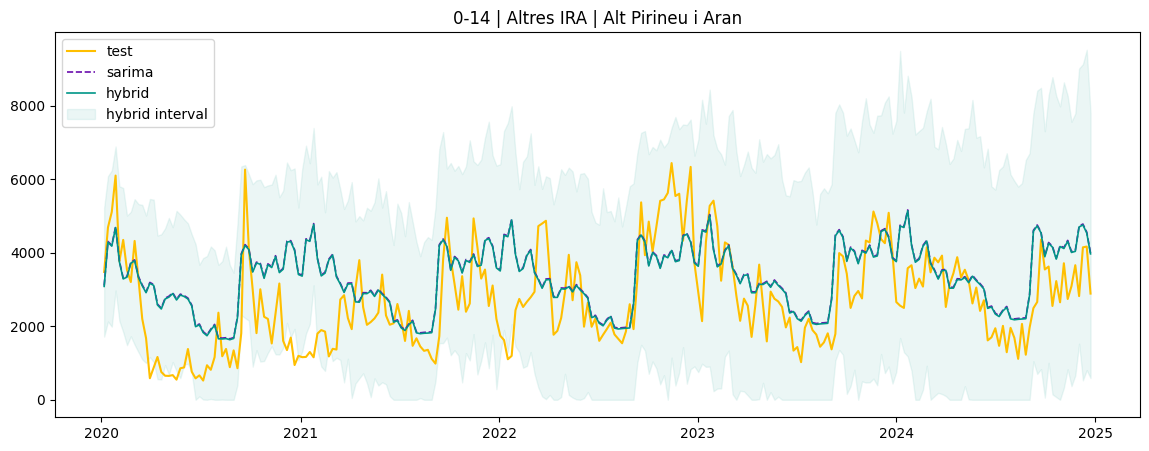

In [8]:
row, pred_df, plot_data = run_one_hybrid(df, sarima_results_ok, "0-14", "Altres IRA", "Alt Pirineu i Aran")

display(pd.DataFrame([row]))

plot_hybrid_comparison(
    plot_data["train"],
    plot_data["test"],
    plot_data["sarima_pred"],
    plot_data["hybrid_pred"],
    low=plot_data["hybrid_low"],
    up=plot_data["hybrid_up"],
    title="0-14 | Altres IRA | Alt Pirineu i Aran"
)

## Automatització completa

S’aplica el pipeline híbrid a totes les sèries amb un SARIMA vàlid.

In [9]:
rows_hybrid = []
preds_hybrid = []

for i, (age, diag, region) in enumerate(combinacions, start=1):
    print(f"{i}/{len(combinacions)} - {age} | {diag} | {region}")

    try:
        row, pred_df, _ = run_one_hybrid(df, sarima_results_ok, age, diag, region)
        rows_hybrid.append(row)

        if pred_df is not None:
            preds_hybrid.append(pred_df)

    except KeyboardInterrupt:
        print("Execution interrupted by user.")
        raise

    except Exception as e:
        rows_hybrid.append({
            "age": age,
            "diag": diag,
            "region": region,
            "status": "fail",
            "error": str(e)
        })

1/174 - 0-14 | Altres IRA | Alt Pirineu i Aran
2/174 - 0-14 | Altres IRA | Barcelona Ciutat


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/mlemodel.py:3661: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  initial_state = random_state.multivariate_normal(


3/174 - 0-14 | Altres IRA | Barcelona Metropolitana Nord


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/mlemodel.py:3661: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  initial_state = random_state.multivariate_normal(


4/174 - 0-14 | Altres IRA | Barcelona Metropolitana Sud


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/mlemodel.py:3661: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  initial_state = random_state.multivariate_normal(


5/174 - 0-14 | Altres IRA | Camp de Tarragona
6/174 - 0-14 | Altres IRA | Catalunya Central
7/174 - 0-14 | Altres IRA | Girona
8/174 - 0-14 | Altres IRA | Lleida
9/174 - 0-14 | Altres IRA | PenedÃ¨s
10/174 - 0-14 | Altres IRA | Terres de l'Ebre
11/174 - 0-14 | Bronquiolitis | Alt Pirineu i Aran
12/174 - 0-14 | Bronquiolitis | Barcelona Ciutat
13/174 - 0-14 | Bronquiolitis | Barcelona Metropolitana Nord
14/174 - 0-14 | Bronquiolitis | Barcelona Metropolitana Sud
15/174 - 0-14 | Bronquiolitis | Camp de Tarragona
16/174 - 0-14 | Bronquiolitis | Catalunya Central
17/174 - 0-14 | Bronquiolitis | Girona
18/174 - 0-14 | Bronquiolitis | Lleida
19/174 - 0-14 | Bronquiolitis | PenedÃ¨s
20/174 - 0-14 | Bronquiolitis | Terres de l'Ebre
21/174 - 0-14 | COVID-19 | Barcelona Ciutat
22/174 - 0-14 | COVID-19 | Girona
23/174 - 0-14 | COVID-19 | Lleida
24/174 - 0-14 | COVID-19 | PenedÃ¨s
25/174 - 0-14 | Escarlatina | Alt Pirineu i Aran
26/174 - 0-14 | Escarlatina | Barcelona Ciutat
27/174 - 0-14 | Escarl

## Fitxers de sortida

Es desen dos fitxers: `results_hybrid.csv`, amb el resum de mètriques, i `preds_hybrid.csv`, amb les prediccions setmanals.

In [10]:
results_hybrid = pd.DataFrame(rows_hybrid)
results_hybrid.to_csv("results_hybrid.csv", index=False)

if len(preds_hybrid) > 0:
    preds_hybrid_df = pd.concat(preds_hybrid, ignore_index=True)
    preds_hybrid_df.to_csv("preds_hybrid.csv", index=False)

print("Files saved:")
print("- results_hybrid.csv")
print("- preds_hybrid.csv")

Files saved:
- results_hybrid.csv
- preds_hybrid.csv


## Comprovació final

Es revisa quantes sèries s’han ajustat correctament i quines han fallat.

In [11]:
results = pd.read_csv("results_hybrid.csv")
results["status"].value_counts()

status
ok      160
fail     14
Name: count, dtype: int64

In [12]:
results[results["status"] == "fail"][["age", "diag", "region", "error"]].head(20)

,age,diag,region,error
20,0-14,COVID-19,Barcelona Ciutat,Burn (54) is greater than or equal to residual...
21,0-14,COVID-19,Girona,Burn (54) is greater than or equal to residual...
22,0-14,COVID-19,Lleida,Burn (54) is greater than or equal to residual...
23,0-14,COVID-19,PenedÃ¨s,Burn (54) is greater than or equal to residual...
104,15+,COVID-19,Alt Pirineu i Aran,Burn (54) is greater than or equal to residual...
105,15+,COVID-19,Barcelona Ciutat,Burn (54) is greater than or equal to residual...
106,15+,COVID-19,Barcelona Metropolitana Nord,Burn (54) is greater than or equal to residual...
107,15+,COVID-19,Barcelona Metropolitana Sud,Burn (54) is greater than or equal to residual...
108,15+,COVID-19,Camp de Tarragona,Burn (53) is greater than or equal to residual...
109,15+,COVID-19,Catalunya Central,Burn (54) is greater than or equal to residual...
